# RL1 - Notebook 2 - Dynamic Programming


In this notebook, you will build on the concepts from the previous notebook to predict the expected return conditioned on the current state, $s$, and a control policy, $\pi$. We call this conditional expectation the state value function, or simply the value function and write this as:
$$
v^{\pi}(s) = \mathbb{E}\left[\left.
\sum_{k=0}^{\infty} \gamma^{k} r_{t+k+1}
\right\vert
s_t = s, \pi
\right]
$$
where $s_t$ is the state at time $t$ and $r_{t+1}$ is the reward received following taking an action at time $t$. Note that the conditioning on $\pi$ essentially means that at every time step $t'$ the actions are sampled from the policy $\pi$, i.e.
$$
a_{t'} \sim p(a_{t'}|s_{t'}, \pi)
$$
where $p(a|s, \pi) = \pi(s,a)$.

As shown in the lectures, the value function is only well defined if the Markov assumption holds. Under these circumstances, we can rewrite it as:
$$
v^{\pi}(s) = \mathbb{E}\left[\left.
 r_{t+k+1} + \gamma v^{\pi}(s)
\right\vert
s_t = s, s_{t+1}=s', \pi
\right]
$$
Or more practically,
$$
v^{\pi}(s) = \sum_{a \in \mathcal{A}} \pi(s,a) \sum_{s' \in \mathcal{S}} t(s,a,s') \left( r(s,a,s') + \gamma v^{\pi}(s')\right)
$$
And we can estimate the value function with a set of estimates $\hat{v}^{\pi}(s)$ for every state $s\in \mathcal{S}$ by starting with arbitrary initial values for $\hat{v}^{\pi}$ and repeatedly applying the following update for all states $s$:
$$
\hat{v}^{\pi}(s) \leftarrow \sum_{a \in \mathcal{A}} \pi(s,a)  \sum_{s' \in \mathcal{S}}t(s,a,s') \left( r(s,a,s') + \gamma \hat{v}^{\pi}(s')\right)
$$

This is called **policy evaluation** and requires us to define a policy $\pi$ to evaluate.


In this notebook, we will show this applied first to the stair-climbing MDP you saw in the previous notebook, and then to larger MDPs based on the grid-world paradigm, in which agents move around a 2 dimensional discrete grid of locations.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

from inst0075.rl.algorithms.dynamic_programming import policy_evaluation
from inst0075.rl.algorithms.dynamic_programming import policy_iteration
from inst0075.rl.environment.states_and_actions import get_unbiased_policy
from inst0075.rl.environment.states_and_actions import dominant_actions
from inst0075.rl.environment.states_and_actions import indices_to_names
from inst0075.rl.visualisation import (
    plot_mdp_matrices,
    plot_policy_matrix,
    report_mdp_summary
)


import inst0075.rl.environment.model.example_grid_worlds as example_grid_worlds 



## Creating grid world MDPs

Here we will construct larger MDPs than we have so far seen. These are built around a conceptual idea of a mobile agent, such as a robot, moving around a discrete grid of locations. Each step the agent can move from one cell to an adjacent cell and has actions N(orth), E(ast), S(outh) and W(est) to do so. The actions are, in general, noisy, meaning that if an agent chooses to move in a given direction then this may result in the agent landing in a different adjoining cell. There are also walls in the environment which block the agent's movement. If the agents movement takes it towards a wall then the movement is not allowed and the agent stays where it is.

The next code cell creates a predefined grid-world and then reports on its basic properties, including a representation (a map) of its locations and their names. 

You can experiment with creating different predefined grid-worlds. Look in `inst0075.rl.environment.model.example_grid_worlds` for available options.


,Property,Value
0,States,16
1,Actions,4
2,State Names,"s00, s01, s02, s03, s04, s05, s06, s07, s08, s..."
3,Action Names,"N, E, S, W"
4,Initial State Distribution,"[0.0, 0.071, 0.071, 0.071, 0.071, 0.071, 0.071..."


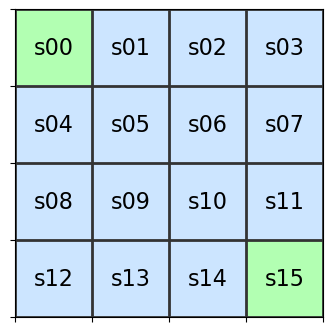

In [2]:
gw = example_grid_worlds.grid_world1()
# Construct and display MDP summary
grid_world_summary = report_mdp_summary(gw)
display(grid_world_summary)

# Visually represent the grid world
_ = gw.visualise()


### Initialising a policy

In order to estimate our value function with $\hat{v}^{\pi}$ we need to specify a policy $\pi$. At this stage, we do not know in general what policy to choose and a good default choice is the unbiassed policy. This assigns equal probability to all actions in all states. 

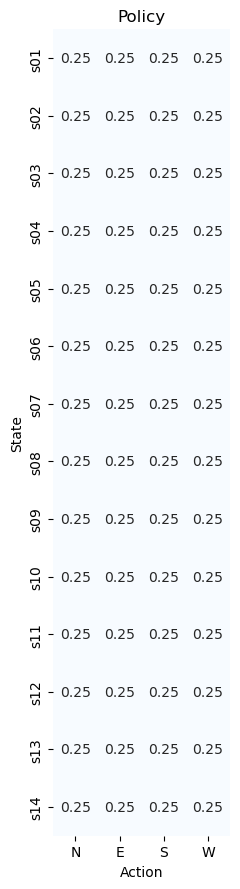

In [3]:
# 
num_states = gw.num_states
num_actions = gw.num_actions
policy = get_unbiased_policy(num_states, num_actions)

# Show heatmap of the policy
plot_policy_matrix(policy, gw)

### Evaluating the unbiased policy

We are now in a position to use **dynamic programming** to estimate the value function $\hat{v}^{\pi}$ for our unbiased policy $\pi$. For ease of interpretation, we visualise the learned value function at the locations of the grid-world. 

(<Figure size 400x400 with 1 Axes>, <AxesSubplot:>)

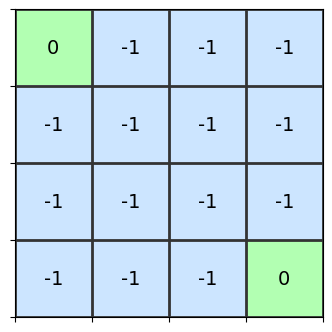

In [4]:
gamma = 0.9
V = policy_evaluation(gw, gamma, policy, max_iterations=1)
gw.visualise(labels=V)


### Greedy policy selection

As discussed in the lectures, we can now use this value function to choose an improved policy. The simple rule is that we choose to always perform the greedy action. The greedy action is the one with the largest immediate reward plus discounted next state value using estimates $\hat{v}^{\pi}$. In other words, we choose new policy $\pi'$ such that:

$$
\pi'(s,a)= 
\begin{cases}
1 & \text{if } a = \arg\max_{b}  \sum_{s' \in \mathcal{S}}t(s,b,s') \left( r(s,b,s') + \gamma \hat{v}^{\pi}(s')\right) \\
0 & \text{otherwise}
\end{cases}
$$

This step is performed in the cell below. The `updated_policy` variable is the new policy, $\pi'$. Visualising this we see that it is no longer the unbiased policy.


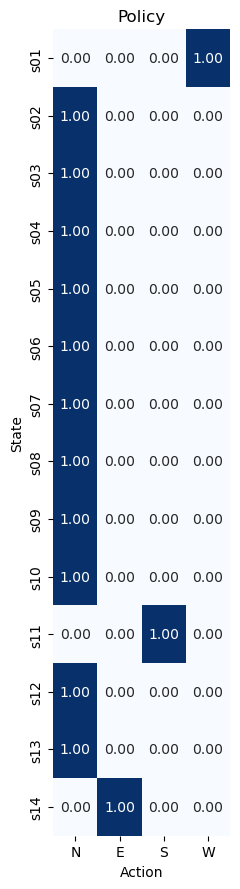

In [5]:
# Define shorthand for transition and reward functions
r = gw.r
t = gw.t
# Make a copy of the policy.
updated_policy = np.copy(policy)
for s, is_nextabsorbing in enumerate(gw.absorbing):
    # Calculate an expected value for each action from this state
    action_values = np.zeros(num_actions)
    for a in range(num_actions):
        # Evaluate the sum over next step states.
        for s_next in range(num_states):
            action_values[a] += t(s,a,s_next)*(r(s,a,s_next) + gamma*V[s_next])
    new_best_action = np.argmax(action_values)
    # Updated policy reflects the new best action for s
    updated_policy[s,:] = 0
    updated_policy[s,new_best_action] = 1
# Show heatmap of the updated policy
plot_policy_matrix(updated_policy, gw)

We can also indicate the dominant actions (those with the highest probabilities) within the map of our grid-world for easy interpretation. It may be possible to see that in some states the associated action is not yet optimal.

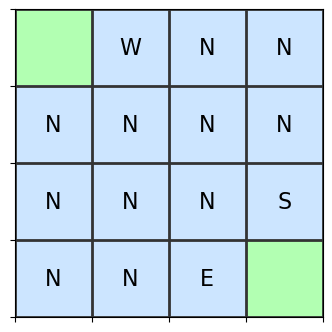

In [6]:
# Get the dominant actions for each state
deterministic_policy = dominant_actions(updated_policy)
greedy_actions = indices_to_names(deterministic_policy, gw.action_names)
# Show dominant actions in the grid-world map.
_ = gw.visualise(labels=greedy_actions, suppress_absorbing=True)

## Policy iteration

Policy evaluation followed by a greedy choice above when applied to a simple MDP may find an optimal policy in a single step, but more generally we need to repeatedly evaluate our running policy then updating the policy to greedily choose actions based on our latest value function. **Policy iteration** does just that, and checks to see whether the policy changes after each update. As soon as the policy does not change, we are guaranteed to be at the optimal policy (given our Markov assumption).

Below we apply policy iteration to the grid-world and show the resulting policy, first as a table of probabilities then as the deterministic actions in the grid-world map. 

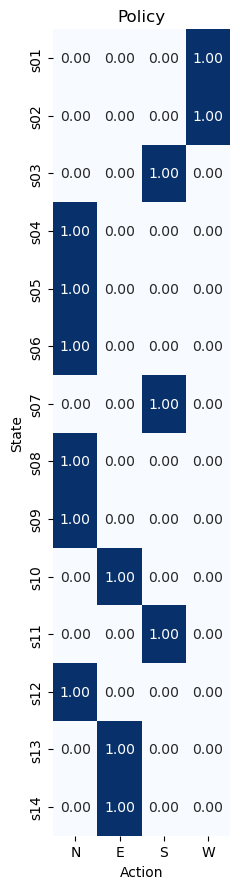

In [7]:
# Update the policy
policy = policy_iteration(gw, gamma)
# Show heatmap of the policy
plot_policy_matrix(policy, gw)

(<Figure size 400x400 with 1 Axes>, <AxesSubplot:>)

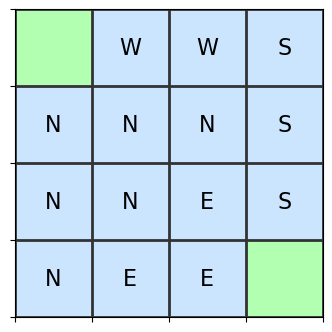

In [8]:
# Get the dominant actions for each state
deterministic_policy = dominant_actions(policy)
best_actions = indices_to_names(deterministic_policy, gw.action_names)
# Show dominant actions in the grid-world map.
gw.visualise(labels=best_actions, suppress_absorbing=True)

## Summary and reflection

In this notebook, you have:
* Created a grid-world MDP and an associated initial unbiased policy
* Applied **policy evaluation** to estimate the value function associated with this policy
* Greedily chosen actions at each state to maximise expected return given this value function estimate, and seen that while this improves actions in some states it is not optimial everywhere.
* Applied **policy iteration** to repeatedly evaluate and greedily update policies until convergence on the optimal policy.

You can experiment with different MDPs available within modules `inst0075.rl.environment.model.example_mdps` and `inst0075.rl.environment.model.example_grid_worlds`. You can also define your own MDPs and grid-worlds and experiment with these.